In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [ ]:
hela_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.genomic.pkl"
hela_genomic_df = pd.read_pickle(hela_genomic_df)
hela_genomic_df = hela_genomic_df[hela_genomic_df["count_all"] >= 20]
print(hela_genomic_df)

In [ ]:
hek_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
hek_genomic_df = pd.read_pickle(hek_genomic_df)
hek_genomic_df = hek_genomic_df[hek_genomic_df["count_all"] >= 20]
print(hek_genomic_df)

In [ ]:
hek_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")
hela_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")

In [ ]:
hek_label = hek_label.reset_index(drop=True)
hek_genomic_df = hek_genomic_df.reset_index(drop=True)
hela_label = hela_label.reset_index(drop=True)
hela_genomic_df = hela_genomic_df.reset_index(drop=True)

In [ ]:
hek_fdr_threshold = 0.61
hela_fdr_threshold = 0.64

In [ ]:
hek_genomic_df = hek_genomic_df[["genome_id","pm6a","dom","count_all"]].reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")
hela_genomic_df = hela_genomic_df[["genome_id","pm6a","dom","count_all"]].reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [ ]:
hek_genomic_df["pos"] = hek_genomic_df["genome_id"].apply(lambda x: int(x.split(":")[2]))
hela_genomic_df["pos"] = hela_genomic_df["genome_id"].apply(lambda x: int(x.split(":")[2]))

In [580]:
hela_df = hela_genomic_df[(hela_genomic_df["gene_id"].apply(len) == 1)&(hela_genomic_df["5mer"].apply(len) == 1)].copy()
hek_df = hek_genomic_df[(hek_genomic_df["gene_id"].apply(len) == 1)&(hek_genomic_df["5mer"].apply(len) == 1)].copy()

hela_df["gene_id"] = np.concatenate(hela_df["gene_id"].values)
hek_df["gene_id"] = np.concatenate(hek_df["gene_id"].values)
hela_df["5mer"] = np.concatenate(hela_df["5mer"].values)
hek_df["5mer"] = np.concatenate(hek_df["5mer"].values)


In [581]:
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

In [582]:
refflat_df = utils.parse_refflat_v2()
refflat_groupby_gene_id = refflat_df[refflat_df["coding"]].groupby("gene_id")


In [684]:
print(refflat_df["exonEnds"][0])

[127588565 127589163 127589594 127590137 127591088 127591700]


In [697]:
def add_utr(df, refflat_groupby_gene_id):
    concat_list = []
    df_groupby_gene_id = df.groupby("gene_id")
    df["pos"] = df["genome_id"].apply(lambda x: int(x.split(":")[2]))
    for gene_id, group in tqdm.tqdm(df_groupby_gene_id):
        if gene_id in refflat_groupby_gene_id.groups:
            refflat_group = refflat_groupby_gene_id.get_group(gene_id)
            min_cds_start = refflat_group["cdsStart"].min()
            max_cds_end = refflat_group["cdsEnd"].max()
            group["in_cds"] = (group["pos"] >= min_cds_start) & (group["pos"] <= max_cds_end)
            assert np.all(refflat_group["strand"].values == refflat_group["strand"].values[0])
            strand = refflat_group["strand"].values[0]
            if strand == "+":
                group["in_3utr"] = group["pos"] >= max_cds_end
                group["in_5utr"] = group["pos"] < min_cds_start
            else:
                group["in_3utr"] = group["pos"] < min_cds_start
                group["in_5utr"] = group["pos"] >= max_cds_end
            all_exon_junctions = np.concatenate([np.concatenate(refflat_group["exonStarts"].values), np.concatenate(refflat_group["exonEnds"].values)])
            tolerance = 5
            all_exon_junctions = np.stack([all_exon_junctions]*len(group), axis=0)
            group["near_ejc"] = np.any(np.abs(all_exon_junctions - group["pos"].values[:, None]) <= tolerance, axis=1)
        else:
            group["in_cds"] = False
            group["in_3utr"] = False
            group["in_5utr"] = False
            group["near_ejc"] = False
        concat_list.append(group)
    df = pd.concat(concat_list, axis=0)
    return df


In [698]:

hek_df = add_utr(hek_df, refflat_groupby_gene_id)
hela_df = add_utr(hela_df, refflat_groupby_gene_id)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11803/11803 [01:16<00:00, 154.29it/s]


In [1067]:
hek_df["log_depth_bin"] = pd.cut(np.log10(hek_df["depth"]), bins=np.arange(1, 5, 1.0)).apply(lambda x: x.left).astype(str)
hela_df["log_depth_bin"] = pd.cut(np.log10(hela_df["depth"]), bins=np.arange(1, 5, 1.0)).apply(lambda x: x.left).astype(str)

In [1068]:
hela_non_cds = hela_df[hela_df["in_3utr"] & ~hela_df["near_ejc"]].dropna()
hek_non_cds = hek_df[hek_df["in_3utr"] & ~hek_df["near_ejc"]].dropna()

print(len(hela_non_cds), len(hek_non_cds))

3476747 4124749


In [1069]:
print(hek_df["in_5utr"].sum(), hela_df["in_5utr"].sum())
print(hek_df["in_3utr"].sum(), hela_df["in_3utr"].sum())
print(hek_df["in_cds"].sum(), hela_df["in_cds"].sum())

332736 276382
4163274 3512512
6170778 5401570


In [1070]:
hela_df_m6a = hela_non_cds[(hela_non_cds["pm6a"] > hela_fdr_threshold)].copy()
hek_df_m6a = hek_non_cds[(hek_non_cds["pm6a"] > hek_fdr_threshold)].copy()

hek_m6a_drach = hek_df_m6a[hek_df_m6a["drach"]]
hela_m6a_drach = hela_df_m6a[hela_df_m6a["drach"]]
hek_m6a_nondrach = hek_df_m6a[~hek_df_m6a["drach"]]
hela_m6a_nondrach = hela_df_m6a[~hela_df_m6a["drach"]]

m6a_df_dict = {"hek_drach": hek_m6a_drach, "hela_drach": hela_m6a_drach, "hek_nondrach": hek_m6a_nondrach, "hela_nondrach": hela_m6a_nondrach}

In [1071]:
hela_ca = hela_non_cds[hela_non_cds["pm6a"] <= hela_fdr_threshold].copy()
hek_ca = hek_non_cds[hek_non_cds["pm6a"] <= hek_fdr_threshold].copy()

In [1072]:
hek_ca_drach = hek_ca[hek_ca["drach"]]
hela_ca_drach = hela_ca[hela_ca["drach"]]
hek_ca_nondrach = hek_ca[~hek_ca["drach"]]
hela_ca_nondrach = hela_ca[~hela_ca["drach"]]
ca_df_dict = {"hek_drach": hek_ca_drach, "hela_drach": hela_ca_drach, "hek_nondrach": hek_ca_nondrach, "hela_nondrach": hela_ca_nondrach}

In [1073]:
sampled_ca_dict = {}
sampled_m6a_dict = {}
for key in ["hek_drach", "hela_drach", "hek_nondrach", "hela_nondrach"]:
    sampled_ca_list = []
    sampled_m6a_list = []
    
    ca_df = ca_df_dict[key]
    m6a_df = m6a_df_dict[key]
    ca_motif_grouped = ca_df.groupby(["5mer", "log_depth_bin", "gene_id"])
    m6a_motif_grouped = m6a_df.groupby(["5mer", "log_depth_bin", "gene_id"])
    ca_keys_as_str = [f"{x[0]}={x[1]}={x[2]}" for x in ca_motif_grouped.groups.keys()]
    m6a_keys_as_str = [f"{x[0]}={x[1]}={x[2]}" for x in m6a_motif_grouped.groups.keys()]
    common_keys = set(ca_keys_as_str).intersection(set(m6a_keys_as_str))
    for keys in tqdm.tqdm(common_keys):
        keys = tuple(keys.split("="))
        ca_group = ca_motif_grouped.get_group(keys)
        m6a_group = m6a_motif_grouped.get_group(keys)
        if len(m6a_group) >= len(ca_group):
            sampled_ca_list.append(ca_group)
            sampled_m6a_list.append(m6a_group.sample(len(ca_group), replace=False))
        else:
            sampled_ca_list.append(ca_group.sample(len(m6a_group), replace=False))
            sampled_m6a_list.append(m6a_group)
    sampled_ca_dict[key] = pd.concat(sampled_ca_list, axis=0)
    sampled_m6a_dict[key] = pd.concat(sampled_m6a_list, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1733/1733 [00:05<00:00, 298.88it/s]


In [1074]:
import pyBigWig
phylop = "/extdata4/baeklab/Hyeonseo/m6A/res/hg38.phyloP100way.bw"
# phylop = "/extdata4/baeklab/Hyeonseo/m6A/res/cactus241way.phyloP.bw"
phylop = pyBigWig.open(phylop)

In [1075]:
def get_phylop_score(df, phylop):
    df["chr"] = df["genome_id"].apply(lambda x: x.split(":")[0])
    df["pos"] = df["genome_id"].apply(lambda x: int(x.split(":")[2]))
    df["phylop"] = df.apply(lambda x: np.mean(phylop.values(x["chr"], x["pos"]-2, x["pos"]+3)), axis=1)
    return df

In [1076]:
for key in sampled_ca_dict.keys():
    sampled_ca_dict[key] = get_phylop_score(sampled_ca_dict[key], phylop)

In [1077]:
for key in sampled_m6a_dict.keys():
    sampled_m6a_dict[key] = get_phylop_score(sampled_m6a_dict[key], phylop)

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-

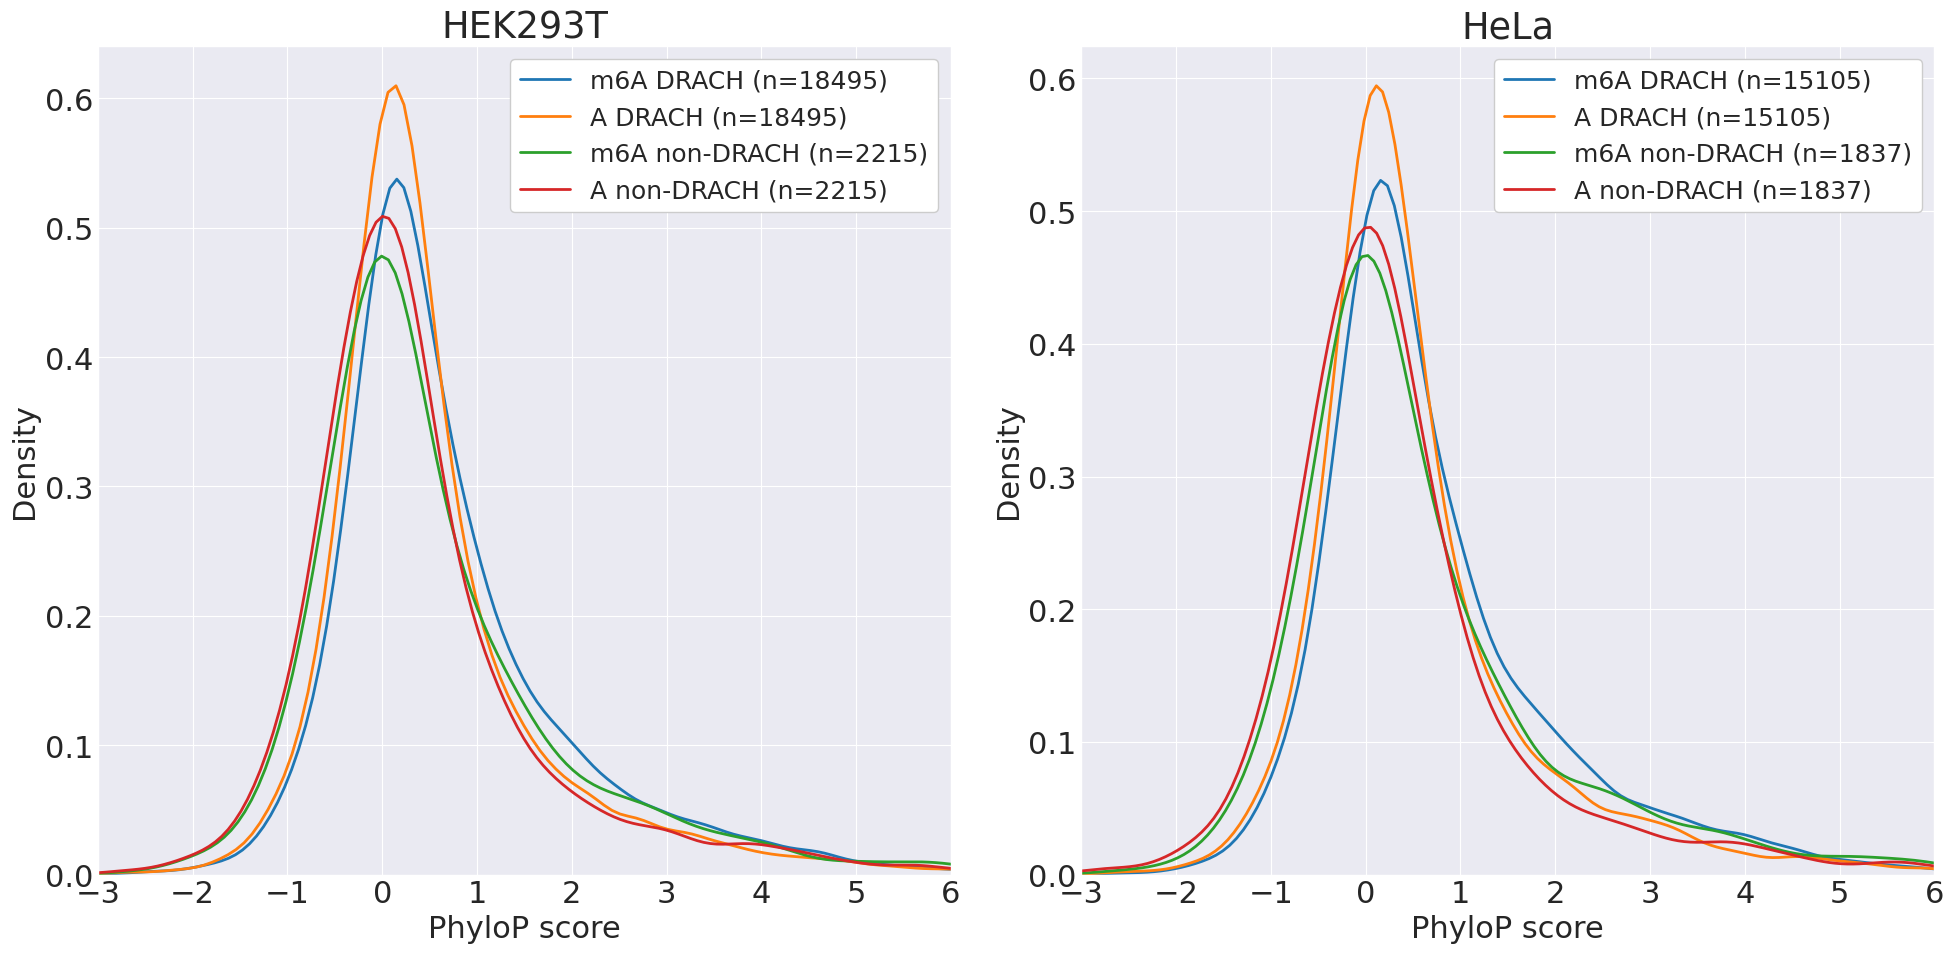

In [1078]:
## Plot KDE
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
## ax1: hek
sns.kdeplot(sampled_m6a_dict["hek_drach"]["phylop"], ax=ax[0], label=f"m6A DRACH (n={len(sampled_m6a_dict['hek_drach'])})")
sns.kdeplot(sampled_ca_dict["hek_drach"]["phylop"], ax=ax[0], label=f"A DRACH (n={len(sampled_ca_dict['hek_drach'])})")
sns.kdeplot(sampled_m6a_dict["hek_nondrach"]["phylop"], ax=ax[0], label=f"m6A non-DRACH (n={len(sampled_m6a_dict['hek_nondrach'])})")
sns.kdeplot(sampled_ca_dict["hek_nondrach"]["phylop"], ax=ax[0], label=f"A non-DRACH (n={len(sampled_ca_dict['hek_nondrach'])})")
ax[0].set_title("HEK293T")
ax[0].set_xlabel("PhyloP score")
ax[0].set_ylabel("Density")
ax[0].legend(fontsize=18)
ax[0].set_xlim(-3, 6)
## ax2: hela
sns.kdeplot(sampled_m6a_dict["hela_drach"]["phylop"], ax=ax[1], label=f"m6A DRACH (n={len(sampled_m6a_dict['hela_drach'])})")
sns.kdeplot(sampled_ca_dict["hela_drach"]["phylop"], ax=ax[1], label=f"A DRACH (n={len(sampled_ca_dict['hela_drach'])})")
sns.kdeplot(sampled_m6a_dict["hela_nondrach"]["phylop"], ax=ax[1], label=f"m6A non-DRACH (n={len(sampled_m6a_dict['hela_nondrach'])})")
sns.kdeplot(sampled_ca_dict["hela_nondrach"]["phylop"], ax=ax[1], label=f"A non-DRACH (n={len(sampled_ca_dict['hela_nondrach'])})")
ax[1].set_title("HeLa")
ax[1].set_xlabel("PhyloP score")
ax[1].set_ylabel("Density")
ax[1].legend(fontsize=18)
ax[1].set_xlim(-3, 6)

plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/phylop_kde.pdf")
plt.show()


KstestResult(statistic=0.0841849148418492, pvalue=1.816992549618616e-57, statistic_location=0.5844000086188317, statistic_sign=-1)
KstestResult(statistic=0.0618510158013544, pvalue=0.00041636977822668685, statistic_location=0.700600006384775, statistic_sign=-1)
KstestResult(statistic=0.11422024255228519, pvalue=6.173640462736854e-23, statistic_location=-0.011999966204166412, statistic_sign=-1)
KstestResult(statistic=0.08255544521681557, pvalue=3.193320469408705e-45, statistic_location=0.7866000011563301, statistic_sign=-1)
KstestResult(statistic=0.06804572672836146, pvalue=0.0004028989896511923, statistic_location=0.9703999727964401, statistic_sign=-1)
KstestResult(statistic=0.11689089096340138, pvalue=5.895780713004054e-20, statistic_location=0.00020000338554382324, statistic_sign=-1)


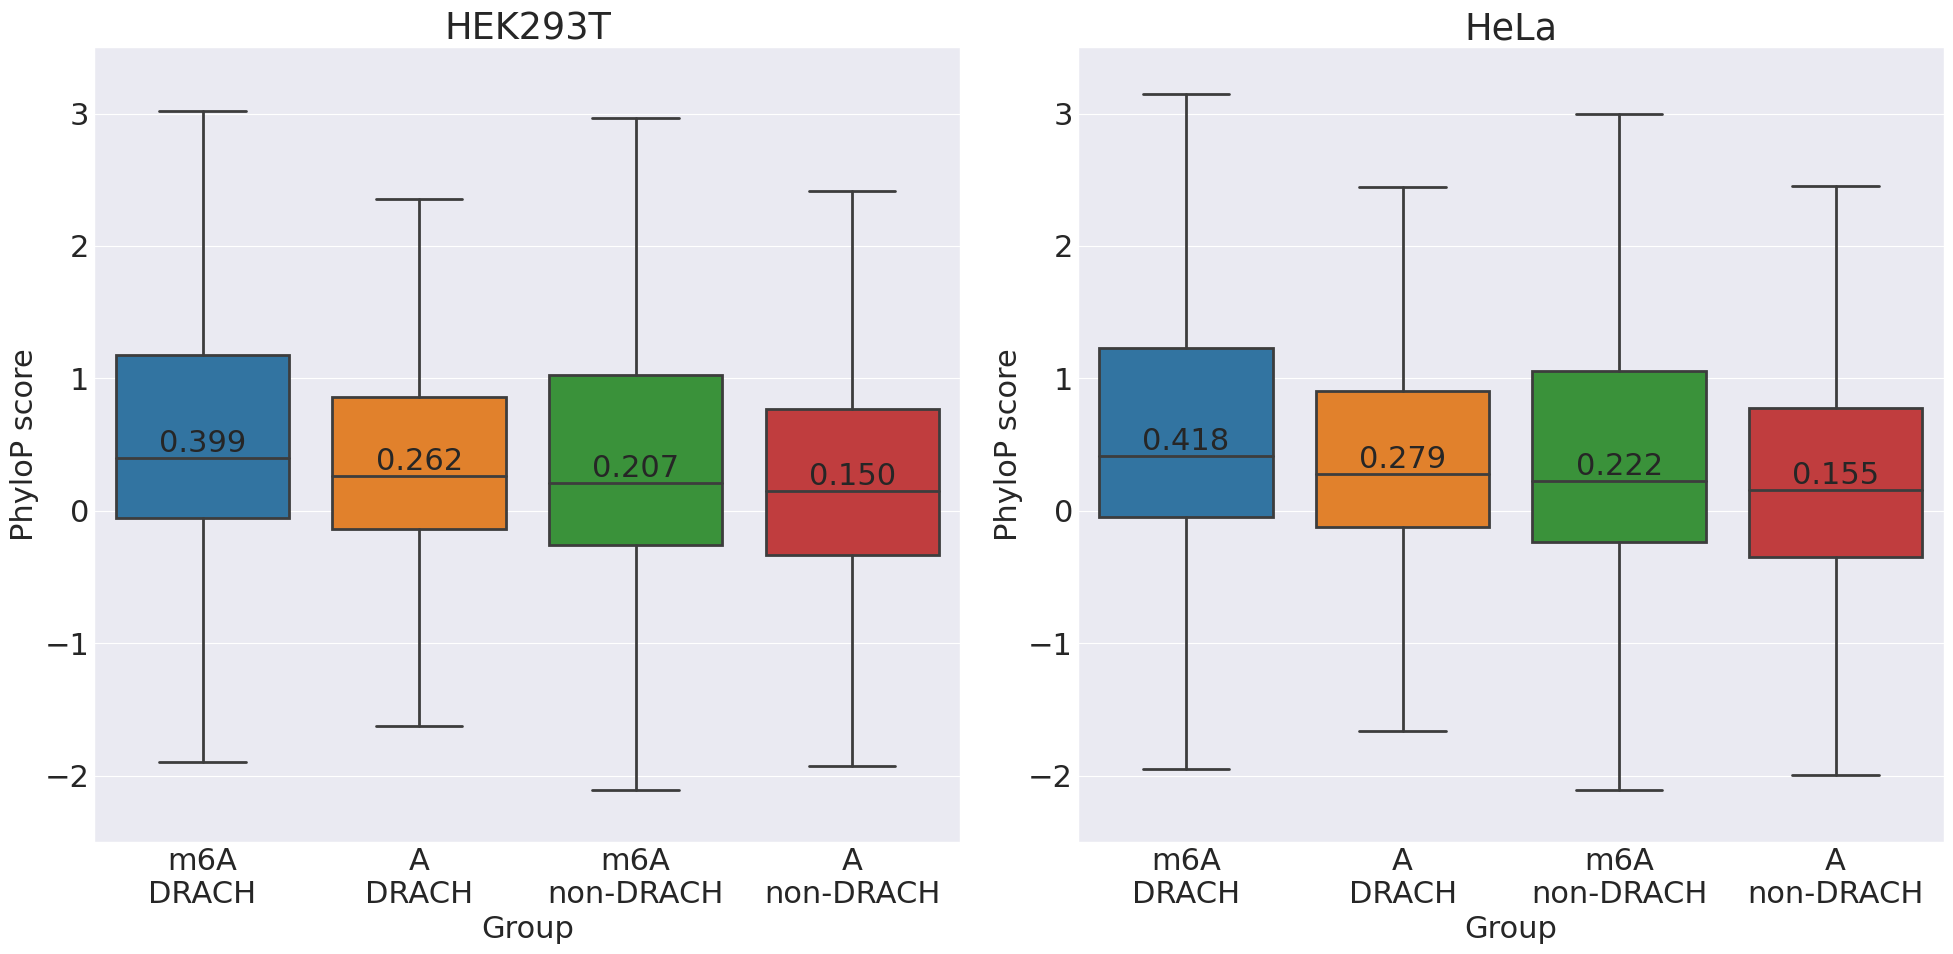

In [1079]:
## Plot Box
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
## ax1: hek
hek_drach_m6a_phylop = sampled_m6a_dict["hek_drach"]["phylop"]
hek_drach_ca_phylop = sampled_ca_dict["hek_drach"]["phylop"]
hek_nondrach_m6a_phylop = sampled_m6a_dict["hek_nondrach"]["phylop"]
hek_nondrach_ca_phylop = sampled_ca_dict["hek_nondrach"]["phylop"]
hek_array = np.concatenate([hek_drach_m6a_phylop, hek_drach_ca_phylop, hek_nondrach_m6a_phylop, hek_nondrach_ca_phylop])
hek_group = ["m6A\nDRACH"] * len(hek_drach_m6a_phylop) + ["A\nDRACH"] * len(hek_drach_ca_phylop) + ["m6A\nnon-DRACH"] * len(hek_nondrach_m6a_phylop) + ["A\nnon-DRACH"] * len(hek_nondrach_ca_phylop)
hek_phylop_df = pd.DataFrame({"phylop": hek_array, "group": hek_group})
sns.boxplot(x="group", y="phylop", data=hek_phylop_df, ax=ax[0], fliersize=0)
## write median for each group
median_list = [hek_drach_m6a_phylop.median(), hek_drach_ca_phylop.median(), hek_nondrach_m6a_phylop.median(), hek_nondrach_ca_phylop.median()]
for i, median in enumerate(median_list):
    ax[0].text(i, median, f"{median:.3f}", ha="center", va="bottom")
## run ks test between m6a and ca
from scipy.stats import ks_2samp
print(ks_2samp(hek_drach_m6a_phylop, hek_drach_ca_phylop))
print(ks_2samp(hek_nondrach_m6a_phylop, hek_nondrach_ca_phylop))
print(ks_2samp(hek_drach_m6a_phylop, hek_nondrach_m6a_phylop))

ax[0].set_title("HEK293T")
ax[0].set_xlabel("Group")
ax[0].set_ylabel("PhyloP score")
ax[0].set_ylim(-2.5, 3.5)


## ax2: hela
hela_drach_m6a_phylop = sampled_m6a_dict["hela_drach"]["phylop"]
hela_nondrach_m6a_phylop = sampled_m6a_dict["hela_nondrach"]["phylop"]
hela_drach_ca_phylop = sampled_ca_dict["hela_drach"]["phylop"]
hela_nondrach_ca_phylop = sampled_ca_dict["hela_nondrach"]["phylop"]
hela_array = np.concatenate([hela_drach_m6a_phylop, hela_drach_ca_phylop, hela_nondrach_m6a_phylop, hela_nondrach_ca_phylop])
hela_group = ["m6A\nDRACH"] * len(hela_drach_m6a_phylop) + ["A\nDRACH"] * len(hela_drach_ca_phylop) + ["m6A\nnon-DRACH"] * len(hela_nondrach_m6a_phylop) + ["A\nnon-DRACH"] * len(hela_nondrach_ca_phylop)
hela_phylop_df = pd.DataFrame({"phylop": hela_array, "group": hela_group})
sns.boxplot(x="group", y="phylop", data=hela_phylop_df, ax=ax[1], fliersize=0)
## write median for each group
median_list = [hela_drach_m6a_phylop.median(), hela_drach_ca_phylop.median(), hela_nondrach_m6a_phylop.median(), hela_nondrach_ca_phylop.median()]
for i, median in enumerate(median_list):
    ax[1].text(i, median, f"{median:.3f}", ha="center", va="bottom")

ax[1].set_title("HeLa")
ax[1].set_xlabel("Group")
ax[1].set_ylabel("PhyloP score")
ax[1].set_ylim(-2.5, 3.5)

## run ks test between m6a and ca
print(ks_2samp(hela_drach_m6a_phylop, hela_drach_ca_phylop))
print(ks_2samp(hela_nondrach_m6a_phylop, hela_nondrach_ca_phylop))
print(ks_2samp(hela_drach_m6a_phylop, hela_nondrach_m6a_phylop))

plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/phylop_box.pdf")
plt.show()

In [1080]:
## print medians(hek)
print(f"{hek_drach_m6a_phylop.median():.3f}, {hek_drach_ca_phylop.median():.3f}, {hek_nondrach_m6a_phylop.median():.3f}, {hek_nondrach_ca_phylop.median():.3f}")
## print medians(hela)
print(f"{hela_drach_m6a_phylop.median():.3f}, {hela_drach_ca_phylop.median():.3f}, {hela_nondrach_m6a_phylop.median():.3f}, {hela_nondrach_ca_phylop.median():.3f}")

0.399, 0.262, 0.207, 0.150
0.418, 0.279, 0.222, 0.155
